In [4]:
# Install required library (safe for Kaggle/Jupyter)
!pip install librosa --quiet
!pip install tensorflow --quiet


In [5]:
import pandas as pd
import numpy as np
import os
import sys
import glob
import warnings

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from IPython.display import Audio

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau


warnings.filterwarnings("ignore")


In [36]:
Ravdess = r"D:\WEB_ML_MAD_project\audio_speech_actors_01-24"
Crema   = r"D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV"
Tess = r"D:\WEB_ML_MAD_project\TESS Toronto emotional speech set data"
Savee   = r"D:\WEB_ML_MAD_project\ALL"


In [37]:
file_emotion, file_path = [], []

for actor_folder in os.listdir(Ravdess):
    actor_path = os.path.join(Ravdess, actor_folder)
    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        part = file.split('.')[0].split('-')
        file_emotion.append(int(part[2]))
        file_path.append(os.path.join(actor_path, file))

Ravdess_df = pd.DataFrame({
    "Emotions": file_emotion,
    "Path": file_path
})

Ravdess_df.Emotions.replace({
    1:'neutral', 2:'calm', 3:'happy', 4:'sad',
    5:'angry', 6:'fear', 7:'disgust', 8:'surprise'
}, inplace=True)

Ravdess_df.head()


,Emotions,Path
0,neutral,D:\WEB_ML_MAD_project\audio_speech_actors_01-2...
1,neutral,D:\WEB_ML_MAD_project\audio_speech_actors_01-2...
2,neutral,D:\WEB_ML_MAD_project\audio_speech_actors_01-2...
3,neutral,D:\WEB_ML_MAD_project\audio_speech_actors_01-2...
4,calm,D:\WEB_ML_MAD_project\audio_speech_actors_01-2...


In [38]:
file_emotion, file_path = [], []

for file in os.listdir(Crema):
    if not file.endswith(".wav"):
        continue

    file_path.append(os.path.join(Crema, file))

    emotion_code = file.split('_')[2]
    mapping = {
        'SAD': 'sad',
        'ANG': 'angry',
        'DIS': 'disgust',
        'FEA': 'fear',
        'HAP': 'happy',
        'NEU': 'neutral'
    }
    file_emotion.append(mapping.get(emotion_code, 'unknown'))

Crema_df = pd.DataFrame({
    "Emotions": file_emotion,
    "Path": file_path
})

Crema_df.head()


,Emotions,Path
0,angry,D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\...
1,disgust,D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\...
2,fear,D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\...
3,happy,D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\...
4,neutral,D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\...


In [39]:
file_emotion, file_path = [], []

for folder in os.listdir(Tess):
    folder_path = os.path.join(Tess, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".wav"):
            continue

        emotion = file.split('_')[2].split('.')[0]
        if emotion == 'ps':
            emotion = 'surprise'

        file_emotion.append(emotion)
        file_path.append(os.path.join(folder_path, file))

Tess_df = pd.DataFrame({
    "Emotions": file_emotion,
    "Path": file_path
})

Tess_df.head()


,Emotions,Path
0,angry,D:\WEB_ML_MAD_project\TESS Toronto emotional s...
1,angry,D:\WEB_ML_MAD_project\TESS Toronto emotional s...
2,angry,D:\WEB_ML_MAD_project\TESS Toronto emotional s...
3,angry,D:\WEB_ML_MAD_project\TESS Toronto emotional s...
4,angry,D:\WEB_ML_MAD_project\TESS Toronto emotional s...


In [40]:
file_emotion, file_path = [], []

for file in os.listdir(Savee):
    file_path.append(Savee + file)
    emotion = file.split('_')[1][:-6]
    mapping = {
        'a':'angry', 'd':'disgust', 'f':'fear',
        'h':'happy', 'n':'neutral', 'sa':'sad'
    }
    file_emotion.append(mapping.get(emotion, 'surprise'))

Savee_df = pd.DataFrame({
    "Emotions": file_emotion,
    "Path": file_path
})


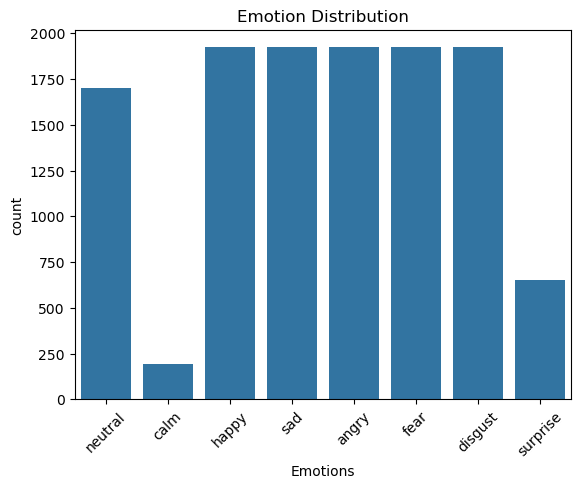

In [41]:
data_path = pd.concat([Ravdess_df, Crema_df, Tess_df, Savee_df], axis=0)
data_path.reset_index(drop=True, inplace=True)

sns.countplot(x=data_path.Emotions)
plt.xticks(rotation=45)
plt.title("Emotion Distribution")
plt.show()


In [42]:
def noise(data):
    return data + 0.035 * np.random.uniform() * np.random.normal(size=len(data))

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate)

def pitch(data, sr, steps=2):
    return librosa.effects.pitch_shift(data, sr, steps)

def extract_features(data, sr):
    features = []
    features.extend(np.mean(librosa.feature.zero_crossing_rate(data).T, axis=0))
    features.extend(np.mean(librosa.feature.mfcc(data, sr=sr, n_mfcc=13).T, axis=0))
    features.extend(np.mean(librosa.feature.rms(data).T, axis=0))
    features.extend(np.mean(librosa.feature.melspectrogram(data, sr=sr).T, axis=0))
    return np.array(features)

def get_features(path):
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    result = []
    result.append(extract_features(data, sr))
    result.append(extract_features(noise(data), sr))
    result.append(extract_features(pitch(stretch(data), sr), sr))
    return result


In [47]:
import numpy as np
import librosa

def noise(data):
    return data + 0.035 * np.random.uniform() * np.random.normal(size=len(data))

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch(data, sr, steps=2):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=steps)

def extract_features(data, sr):
    features = []

    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    features.extend(zcr)

    mfcc = np.mean(
        librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13).T,
        axis=0
    )
    features.extend(mfcc)

    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    features.extend(rms)

    mel = np.mean(
        librosa.feature.melspectrogram(y=data, sr=sr).T,
        axis=0
    )
    features.extend(mel)

    return np.array(features)

def get_features(path):
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    return [
        extract_features(data, sr),
        extract_features(noise(data), sr),
        extract_features(pitch(stretch(data), sr), sr)
    ]


In [48]:
test_path = data_path.Path.iloc[0]
test_feat = get_features(test_path)
print(len(test_feat), test_feat[0].shape)


3 (143,)


In [50]:
# 🔹 CELL 9 — Feature Dataset Creation (IMPORTANT)

X, Y = [], []

for i, (path, emotion) in enumerate(zip(data_path.Path, data_path.Emotions)):
    try:
        for f in get_features(path):
            X.append(f)
            Y.append(emotion)
    except Exception as e:
        print("Error with file:", path)
        print(e)
        continue

    # progress update every 100 files
    if i % 100 == 0:
        print(f"Processed {i}/{len(data_path)} files")

Features = pd.DataFrame(X)
Features['labels'] = Y

print("✅ Feature extraction completed")
print("Feature shape:", Features.shape)
Features.head()



Processed 0/12162 files
Processed 100/12162 files
Processed 200/12162 files
Processed 300/12162 files
Processed 400/12162 files
Processed 500/12162 files
Processed 600/12162 files
Processed 700/12162 files
Processed 800/12162 files
Processed 900/12162 files
Processed 1000/12162 files
Processed 1100/12162 files
Processed 1200/12162 files
Processed 1300/12162 files
Processed 1400/12162 files
Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_ANG_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_DIS_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_FEA_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_HAP_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_NEU_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_DFA_SAD_XX.wav

Error with file: D:\WEB_ML_MAD_project\CREMA-D-master\AudioWAV\1001_IEO_ANG_HI.wav

Error with file: D:

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,labels
0,0.321275,-645.880737,72.619637,0.841305,16.399446,10.241591,0.653901,-4.328002,-4.258932,-14.575824,...,4.310903e-06,3.291511e-06,2.148075e-06,2.279739e-06,0.000005,8.190282e-06,7.024454e-06,5.051209e-06,4.245835e-07,neutral
1,0.387930,-338.222240,13.515343,7.242416,5.401001,3.332310,0.345373,-2.102749,-4.393464,-5.545641,...,7.696716e-04,8.161669e-04,8.088065e-04,8.039117e-04,0.000793,8.111205e-04,8.158439e-04,8.328641e-04,7.983953e-04,neutral
2,0.175297,-703.622009,67.886848,-2.875750,18.077141,3.063382,-4.125680,-9.770417,-8.673470,-14.718939,...,9.860163e-07,5.285361e-07,8.273389e-07,6.289422e-07,0.000001,5.300847e-07,4.321551e-07,1.911227e-07,2.230516e-08,neutral
3,0.293566,-634.663269,72.324066,-2.998578,20.209740,10.674218,-1.151011,-2.813592,-7.923956,-16.231958,...,6.984504e-06,7.034949e-06,6.654923e-06,6.979548e-06,0.000012,9.640184e-06,1.096403e-05,5.543237e-06,4.254087e-07,neutral
4,0.443848,-258.553840,4.133901,4.334604,4.280654,2.596015,0.168862,-0.948026,-2.265087,-3.281415,...,5.018378e-03,5.141022e-03,4.903553e-03,5.050647e-03,0.004869,5.075119e-03,4.988560e-03,5.007535e-03,4.882142e-03,neutral


In [51]:
X = Features.iloc[:, :-1].values
Y = Features['labels'].values

encoder = OneHotEncoder()
Y = encoder.fit_transform(Y.reshape(-1,1)).toarray()

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)


In [52]:
model = Sequential([
    Conv1D(256, 5, activation='relu', padding='same', input_shape=(x_train.shape[1],1)),
    MaxPooling1D(5, strides=2, padding='same'),

    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(5, strides=2, padding='same'),

    Conv1D(64, 5, activation='relu', padding='same'),
    MaxPooling1D(5, strides=2, padding='same'),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(Y.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 143, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 72, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 72, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 36, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,688 (951.91 KB)

 Trainable params: 243,688 (951.91 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
rlrp = ReduceLROnPlateau(patience=2, factor=0.4, min_lr=1e-7)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[rlrp]
)


Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.3519 - loss: 1.7044 - val_accuracy: 0.5090 - val_loss: 1.4701 - learning_rate: 0.0010
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.5059 - loss: 1.3389 - val_accuracy: 0.5912 - val_loss: 1.1527 - learning_rate: 0.0010
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.5828 - loss: 1.1232 - val_accuracy: 0.6293 - val_loss: 1.0082 - learning_rate: 0.0010
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.6249 - loss: 1.0037 - val_accuracy: 0.6478 - val_loss: 0.9370 - learning_rate: 0.0010
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.6457 - loss: 0.9377 - val_accuracy: 0.6490 - val_loss: 0.9411 - learning_rate: 0.0010
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.6721 - loss: 0.8806 - val_accuracy: 0.6792 - val_loss: 0.8486 - learning_rate: 0.0010
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6800 - loss

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7740 - loss: 0.6264
Test Accuracy: 77.39779949188232
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step  
              precision    recall  f1-score   support

       angry       0.88      0.84      0.86       340
        calm       0.35      0.76      0.48       108
     disgust       0.73      0.73      0.73       365
        fear       0.85      0.83      0.84       344
       happy       0.82      0.73      0.77       367
     neutral       0.94      0.80      0.86       296
         sad       0.80      0.75      0.77       388
    surprise       0.74      0.77      0.76       336

    accuracy                           0.77      2544
   macro avg       0.76      0.77      0.76      2544
weighted avg       0.80      0.77      0.78      2544



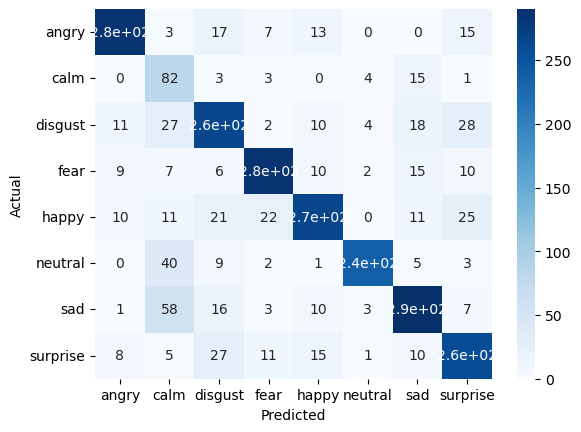

In [54]:
print("Test Accuracy:", model.evaluate(x_test, y_test)[1]*100)

y_pred = encoder.inverse_transform(model.predict(x_test))
y_true = encoder.inverse_transform(y_test)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=encoder.categories_[0],
            yticklabels=encoder.categories_[0])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
